# *IT00CS34 Edge Computing for ML - Spring 26*



# Training using TensorFlow

## Overview

To effectively deploy deep neural models on resource-constrained edge devices, two critical aspects of model optimization are most useful: pruning, which involves reducing the size of a neural network by eliminating unnecessary parameters, and quantization, which involves reducing the precision of numerical values in the model to conserve memory and computational resources.

For using these techniques, we define the application area by employing a small CNN based-architecture trained on rock-paper-scissors dataset by Laurence Moroney. At the end of the notebook, we obtain the trained full-precision model to be used for the further steps of the project.

### Dataset overview
Rock Paper Scissors contains images from a variety of different hands, from different races, ages and genders, posed into Rock / Paper or Scissors and labelled as such. These images have all been generated using CGI techniques as an experiment in determining if a CGI-based dataset can be used for classification against real images.

Note that all of this data is posed against a white background.

Each image is 300×300 pixels in 24-bit color

## Setup

You may need to restart session in google colab after executing the following cell.

In [ ]:
!pip install -q --upgrade tensorflow-model-optimization

In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import tensorflow as tf
from tensorflow_model_optimization.python.core.keras.compat import keras
import numpy as np
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
tf.random.set_seed(
    seed=81
)

## Using Tensorflow Datasets API to load MNIST

TFDS datasets often come with data already split into different sets. For rock_paper_scissors, it has splits for train and test. We use the [Slicing API](https://www.tensorflow.org/datasets/splits#slicing_api) for TFDS to create a validation split.

Next, we aim to understand how the dataset is formatted and utilize visualizations. Finally, the dataset is preprocessed before being passed to the model. For preprocessing, we rescale to a much smaller resolution, convert to grayscale and normalize the image values as float32 within the range [0, 1] for all three splits.

In [ ]:
(dataset_train, dataset_val, dataset_test), ds_info = tfds.load(
    'rock_paper_scissors',
    split=['train[:90%]', 'train[90%:]', 'test'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True,
)

Input image shape: (300, 300, 3)
Image type: <dtype: 'uint8'>
Label shape: ()
Label type: <dtype: 'int64'>


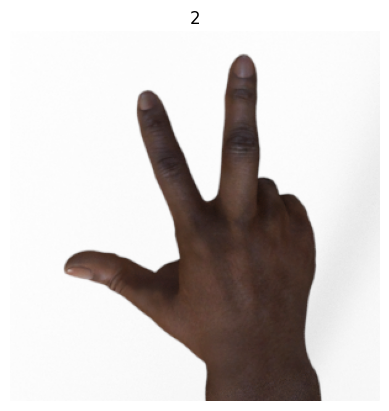

In [ ]:
ds = dataset_train.take(1)  # Only take a single example
for example in ds:  # example is `('image': tf.Tensor, 'label': tf.Tensor)`
  image = example[0]
  label = example[1]
  print(f"Input image shape: {image.shape}\nImage type: {image.dtype}")
  print(f"Label shape: {label.shape}\nLabel type: {label.dtype}")
  plt.imshow(image, cmap='gray')
  plt.title(label.numpy())
  plt.axis("off")
  plt.show()

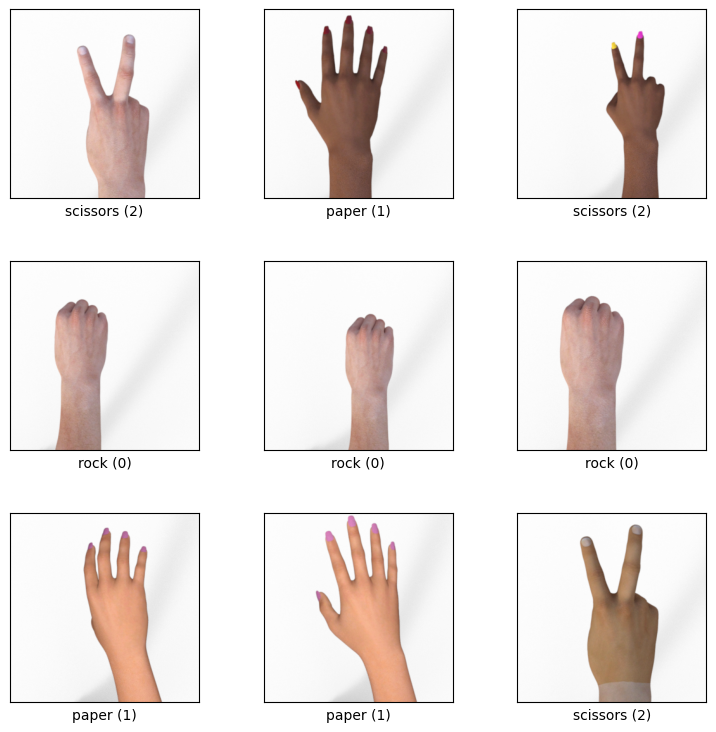

In [ ]:
fig = tfds.show_examples(dataset_test, ds_info)

### Parameters

In [ ]:
batch_size = 32
n_epochs = 8

### Preprocessing

In [ ]:
# Preprocessing function
def preprocess(image, label):
  """applies the target preprocessing to the image and returns preprocessed image with label."""
  image = tf.image.resize(image, (32, 32))  # Resize images
  image = tf.image.rgb_to_grayscale(image)    # Convert to grayscale
  image = tf.cast(image, tf.float32) / 255.0  # Normalize pixel values
  return image, label

In [ ]:
dataset_train = (dataset_train
                 .map(preprocess)
                 .shuffle(1000)
                 .batch(batch_size)
                 .prefetch(tf.data.AUTOTUNE))

dataset_val = (dataset_val
                .map(preprocess)
                .batch(batch_size)
                .prefetch(tf.data.AUTOTUNE))

dataset_test = (dataset_test
                .map(preprocess)
                .batch(batch_size)
                .prefetch(tf.data.AUTOTUNE))

## Training Neural Network

In [ ]:
# Define the model architecture.
model = keras.Sequential([
    keras.layers.Conv2D(8, (3, 3), activation='relu', input_shape=(32, 32, 1)),
    keras.layers.MaxPooling2D(2, 2),

    keras.layers.Conv2D(16, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D(2, 2),

    keras.layers.Conv2D(32, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D(2, 2),

    keras.layers.Flatten(),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(3, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 30, 30, 8)         80        
                                                                 
 max_pooling2d (MaxPooling2  (None, 15, 15, 8)         0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 13, 13, 16)        1168      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 6, 6, 16)          0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 4, 4, 32)          4640      
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 2, 2, 32)          0

In [ ]:
history = model.fit(
  dataset_train,
  validation_data=dataset_val,
  epochs=n_epochs
)


Epoch 1/8
71/71 [==============================] - 14s 61ms/step - loss: 0.9060 - accuracy: 0.6235 - val_loss: 0.6109 - val_accuracy: 0.8056
Epoch 2/8
71/71 [==============================] - 4s 31ms/step - loss: 0.4516 - accuracy: 0.8395 - val_loss: 0.2858 - val_accuracy: 0.9365
Epoch 3/8
71/71 [==============================] - 4s 31ms/step - loss: 0.2374 - accuracy: 0.9369 - val_loss: 0.1402 - val_accuracy: 0.9841
Epoch 4/8
71/71 [==============================] - 5s 50ms/step - loss: 0.1444 - accuracy: 0.9621 - val_loss: 0.0854 - val_accuracy: 0.9921
Epoch 5/8
71/71 [==============================] - 4s 31ms/step - loss: 0.0927 - accuracy: 0.9806 - val_loss: 0.0504 - val_accuracy: 0.9960
Epoch 6/8
71/71 [==============================] - 4s 31ms/step - loss: 0.0656 - accuracy: 0.9846 - val_loss: 0.0345 - val_accuracy: 0.9960
Epoch 7/8
71/71 [==============================] - 4s 35ms/step - loss: 0.0495 - accuracy: 0.9899 - val_loss: 0.0258 - val_accuracy: 0.9960
Epoch 8/8
71/71 [==

In [ ]:
test_loss, baseline_accuracy = model.evaluate(
    dataset_test, verbose=0)

print(f'Test loss: {test_loss:.4f}')
print('Baseline test accuracy:', baseline_accuracy)

Test loss: 0.3357
Baseline test accuracy: 0.8306451439857483


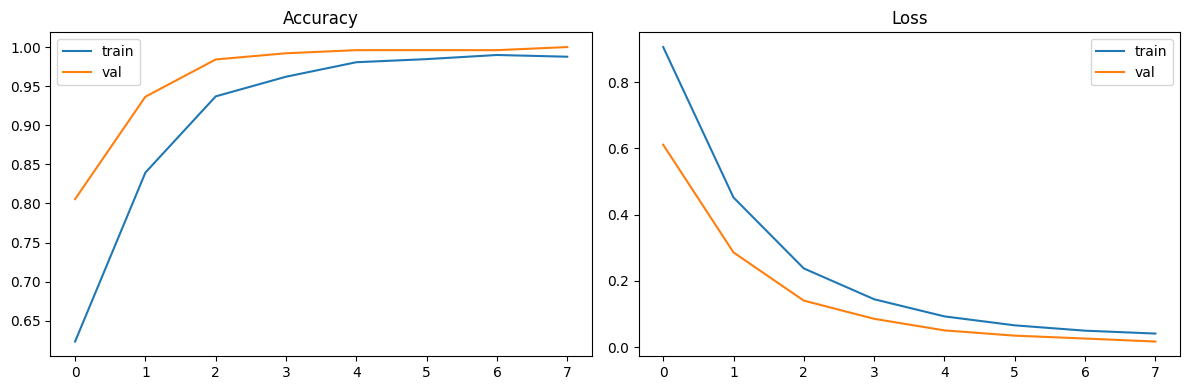

In [ ]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],     label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy'); plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['loss'],     label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss'); plt.legend()
plt.tight_layout(); plt.show()


In [ ]:
# Saving the model in .h5 format
keras.models.save_model(model, '/content/drive/MyDrive/Abo_Akademi/Edge_computing/Full_Precision_RPS.h5', include_optimizer=False)


/tmp/ipykernel_12146/3988626053.py:2: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  keras.models.save_model(model, '/content/drive/MyDrive/Abo_Akademi/Edge_computing/Full_Precision_RPS.h5', include_optimizer=False)


In [ ]:
import os, zipfile, tempfile
def get_gzipped_model_size(model_or_path):
    """Return gzip-compressed model size in KB."""
    if isinstance(model_or_path, str):
        path = model_or_path
    else:
        _, path = tempfile.mkstemp(suffix='.h5')
        keras.models.save_model(model_or_path, path, include_optimizer=False)
    _, zipped = tempfile.mkstemp(suffix='.zip')
    with zipfile.ZipFile(zipped, 'w', compression=zipfile.ZIP_DEFLATED) as f:
        f.write(path)
    return os.path.getsize(zipped) / 1024

print(f'Full-precision compressed size: {get_gzipped_model_size(model):.1f} KB')

Full-precision compressed size: 39.7 KB


/tmp/ipykernel_12146/465317827.py:8: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  keras.models.save_model(model_or_path, path, include_optimizer=False)


In this notebook, we trained a convolutional neural network on the rock-paper-scissors dataset using TensorFlow (and various of its APIs). It's important to note the size of the trained model in terms of the number of trainable parameters and the baseline test accuracy for further comparisons during the pruning and quantization steps.

## Pruning
Experiment with different pruning methods available in tensorflow_model_optimization library and track the test set accuracy and model size.

### Task 1A: apply PolynomialDecay Pruning Schedule on the whole model.

In [ ]:
def build_model():
    return keras.Sequential([
        keras.layers.Conv2D(8,  (3,3), activation='relu', input_shape=(32, 32, 1)),
        keras.layers.MaxPooling2D(2, 2),
        keras.layers.Conv2D(16, (3,3), activation='relu'),
        keras.layers.MaxPooling2D(2, 2),
        keras.layers.Conv2D(32, (3,3), activation='relu'),
        keras.layers.MaxPooling2D(2, 2),
        keras.layers.Flatten(),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(3,  activation='softmax'),
    ])

model = keras.models.load_model('/content/drive/MyDrive/Abo_Akademi/Edge_computing/Full_Precision_RPS.h5')


In [ ]:
import tensorflow_model_optimization as tfmot

In [ ]:
def get_gzipped_model_size(model_or_path):
    if isinstance(model_or_path, str):
        path = model_or_path
    else:
        _, path = tempfile.mkstemp(suffix='.h5')
        keras.models.save_model(model_or_path, path, include_optimizer=False)
    _, zipped = tempfile.mkstemp(suffix='.zip')
    with zipfile.ZipFile(zipped, 'w', compression=zipfile.ZIP_DEFLATED) as f:
        f.write(path)
    return os.path.getsize(zipped) / 1024

def compile_and_fit_pruned(pruned_model, epochs=4):
    pruned_model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    callbacks = [
        tfmot.sparsity.keras.UpdatePruningStep(),
        tfmot.sparsity.keras.PruningSummaries(log_dir=tempfile.mkdtemp()),
    ]
    pruned_model.fit(
        dataset_train, validation_data=dataset_val,
        epochs=epochs, callbacks=callbacks, verbose=1,
    )
    return pruned_model

def evaluate_pruned(stripped_model, label='Pruned'):
    stripped_model.compile(          # add this
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    loss, acc = stripped_model.evaluate(dataset_test, verbose=0)
    weights  = stripped_model.get_weights()
    sparsity = sum(np.sum(w == 0) / w.size for w in weights) / len(weights)
    size_kb  = get_gzipped_model_size(stripped_model)
    print(f'{label:55s}  acc={acc:.4f}  sparsity={sparsity:.2%}  size={size_kb:.1f}KB')
    return acc, sparsity, size_kb

results_1a = []

for final_sparsity in [0.50, 0.80]:
    print(f'\n=== PolynomialDecay – whole model – final_sparsity={final_sparsity} ===')

    num_train_steps  = len(dataset_train) * 4
    pruning_schedule = tfmot.sparsity.keras.PolynomialDecay(
        initial_sparsity=0.0,
        final_sparsity=final_sparsity,
        begin_step=0,
        end_step=num_train_steps,
        frequency=50,
    )

    base = build_model()
    base.set_weights(model.get_weights())

    pruned   = tfmot.sparsity.keras.prune_low_magnitude(base, pruning_schedule=pruning_schedule)
    pruned   = compile_and_fit_pruned(pruned, epochs=4)
    stripped = tfmot.sparsity.keras.strip_pruning(pruned)

    label = f'1A PolynomialDecay whole-model s={int(final_sparsity*100)}%'
    acc, sp, sz = evaluate_pruned(stripped, label)
    results_1a.append((label, acc, sp, sz))
    stripped.save(f'pruned_whole_s{int(final_sparsity*100)}.h5')


=== PolynomialDecay – whole model – final_sparsity=0.5 ===
Epoch 1/4
71/71 [==============================] - 15s 104ms/step - loss: 0.0388 - accuracy: 0.9903 - val_loss: 0.0242 - val_accuracy: 0.9960
Epoch 2/4
71/71 [==============================] - 4s 35ms/step - loss: 0.1018 - accuracy: 0.9660 - val_loss: 0.0176 - val_accuracy: 1.0000
Epoch 3/4
71/71 [==============================] - 6s 62ms/step - loss: 0.0603 - accuracy: 0.9854 - val_loss: 0.0578 - val_accuracy: 0.9881
Epoch 4/4
71/71 [==============================] - 4s 35ms/step - loss: 0.0457 - accuracy: 0.9890 - val_loss: 0.0152 - val_accuracy: 0.9960


/tmp/ipykernel_12146/3141293527.py:7: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  keras.models.save_model(model_or_path, path, include_optimizer=False)
/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


1A PolynomialDecay whole-model s=50%                     acc=0.8360  sparsity=25.29%  size=25.6KB

=== PolynomialDecay – whole model – final_sparsity=0.8 ===
Epoch 1/4
71/71 [==============================] - 12s 37ms/step - loss: 0.0789 - accuracy: 0.9735 - val_loss: 0.0206 - val_accuracy: 1.0000
Epoch 2/4
71/71 [==============================] - 4s 35ms/step - loss: 0.0751 - accuracy: 0.9899 - val_loss: 0.0453 - val_accuracy: 0.9960
Epoch 3/4
71/71 [==============================] - 6s 46ms/step - loss: 0.3222 - accuracy: 0.8999 - val_loss: 0.3150 - val_accuracy: 0.9325
Epoch 4/4
71/71 [==============================] - 4s 36ms/step - loss: 0.2612 - accuracy: 0.9409 - val_loss: 0.1766 - val_accuracy: 0.9881
1A PolynomialDecay whole-model s=80%                     acc=0.9113  sparsity=40.66%  size=14.6KB


### Task 1B: apply layerwise pruning only to the conv2D layers.

For both tasks try different sparsity parameters.

## Quantization
Quantization helps reduce the size and computation requirements of models, making them more efficient, especially for deployment on resource-constrained devices. Here, we only experiment with post-training quantization methods.

The following post-training quantization can be applied to both the base model and the pruned model. Note: all the following tasks will produce different versions of the same model.

In [ ]:
def representative_dataset():
    for images, _ in dataset_val.take(100):
        for img in images:
            yield [tf.expand_dims(img, axis=0)]

### Task 2A: Dynamic Range Quantization

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_dyn  = converter.convert()
path_dyn    = '/content/drive/MyDrive/Abo_Akademi/Edge_computing/model_dynamic_range.tflite'
with open(path_dyn, 'wb') as f:
    f.write(tflite_dyn)

print(f'Dynamic-range quantized: {os.path.getsize(path_dyn)/1024:.1f} KB')

interp = tf.lite.Interpreter(model_path=path_dyn)
interp.allocate_tensors()
print('Task 2A – Dynamic Range')
print('  Input  type:', interp.get_input_details()[0]['dtype'])
print('  Output type:', interp.get_output_details()[0]['dtype'])

Dynamic-range quantized: 15.5 KB
Task 2A – Dynamic Range
  Input  type: <class 'numpy.float32'>
  Output type: <class 'numpy.float32'>


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


### Task 2B: Integer quantization of model parameters with float input/outputs (needs representative dataset)

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]

tflite_int8f = converter.convert()
path_int8f   = '/content/drive/MyDrive/Abo_Akademi/Edge_computing/model_int8_float_io.tflite'
with open(path_int8f, 'wb') as f:
    f.write(tflite_int8f)

print(f'INT8 (float I/O): {os.path.getsize(path_int8f)/1024:.1f} KB')

interp = tf.lite.Interpreter(model_path=path_int8f)
interp.allocate_tensors()
print('Task 2B – INT8 w/ float I/O')
print('  Input  type:', interp.get_input_details()[0]['dtype'])
print('  Output type:', interp.get_output_details()[0]['dtype'])

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


INT8 (float I/O): 17.0 KB
Task 2B – INT8 w/ float I/O
  Input  type: <class 'numpy.float32'>
  Output type: <class 'numpy.float32'>


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


### Task 2C: Full integer quantization (needs representative dataset)

Verify each case with the following code:

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type  = tf.int8
converter.inference_output_type = tf.int8

tflite_full = converter.convert()
path_full   = '/content/drive/MyDrive/Abo_Akademi/Edge_computing/model_full_int8.tflite'
with open(path_full, 'wb') as f:
    f.write(tflite_full)

print(f'Full INT8: {os.path.getsize(path_full)/1024:.1f} KB')

interp = tf.lite.Interpreter(model_path=path_full)
interp.allocate_tensors()
print('Task 2C – Full INT8')
print('  Input  type:', interp.get_input_details()[0]['dtype'])
print('  Output type:', interp.get_output_details()[0]['dtype'])

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Full INT8: 16.7 KB
Task 2C – Full INT8
  Input  type: <class 'numpy.int8'>
  Output type: <class 'numpy.int8'>


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [ ]:
# ── Quantization size comparison ─────────────────────────────────────────
orig_kb = os.path.getsize('/content/drive/MyDrive/Abo_Akademi/Edge_computing/Full_Precision_RPS.h5') / 1024
rows = [
    ('Full precision (.h5)',        orig_kb),
    ('Dynamic Range (.tflite)',     os.path.getsize(path_dyn)   / 1024),
    ('INT8 float I/O (.tflite)',    os.path.getsize(path_int8f) / 1024),
    ('Full INT8 (.tflite)',         os.path.getsize(path_full)  / 1024),
]
print(f'{"Model":40s}  Size(KB)  Reduction')
print('-' * 65)
for name, kb in rows:
    red = f'  ({(1-kb/orig_kb)*100:.1f}% smaller)' if kb < orig_kb else ''
    print(f'{name:40s}  {kb:7.1f}{red}')

Model                                     Size(KB)  Reduction
-----------------------------------------------------------------
Full precision (.h5)                         69.9
Dynamic Range (.tflite)                      15.5  (77.8% smaller)
INT8 float I/O (.tflite)                     17.0  (75.6% smaller)
Full INT8 (.tflite)                          16.7  (76.1% smaller)


## Converting to tflite

Run the following bash command to convert the `your_model.tflite` to arduino (`C`) compatible format, a header file (`model.h`). Save the model for future use.

*Note: Remember to fix the paths.*

In [ ]:
import os
header_path = '/content/drive/MyDrive/Abo_Akademi/Edge_computing/model.h'
tflite_src  = '/content/drive/MyDrive/Abo_Akademi/Edge_computing/model_full_int8.tflite'  # Make sure this matches your final tflite filename

output_dir = os.path.dirname(header_path)
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created missing directory pathway: {output_dir}")

!echo 'const unsigned char model[] = {' > "{header_path}"
!cat "{tflite_src}" | xxd -i            >> "{header_path}"
!echo '};'                              >> "{header_path}"

model_h_size = os.path.getsize(header_path)
print(f'\n🎉 Success! Header file created in Google Drive.')
print(f'Header file model.h is {model_h_size:,} bytes ({model_h_size/1024:.1f} KB)')


🎉 Success! Header file created in Google Drive.
Header file model.h is 105,523 bytes (103.0 KB)


You can check the file size of the final model header by executing the following code.